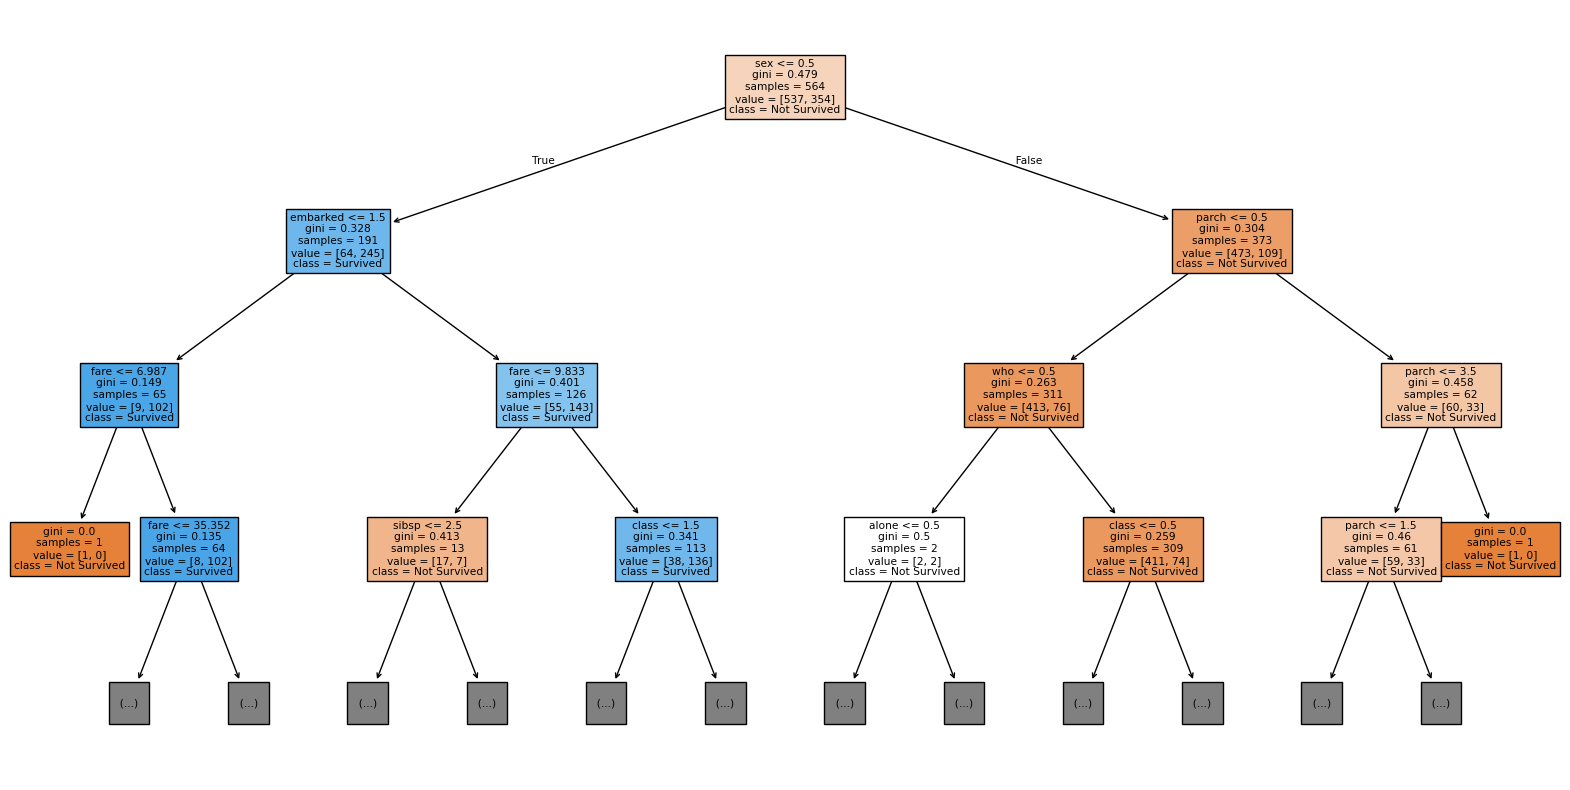

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Titanic.csv")

# Convert categorical columns
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])
df["class"] = le.fit_transform(df["class"])
df["who"] = le.fit_transform(df["who"])
df["alone"] = df["alone"].astype(int)

# Handle missing values
df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# X and y
X = df.drop("survived", axis=1)
y = df["survived"]

# Random Forest
model = RandomForestClassifier(n_estimators=10, random_state=42)

# Train
model.fit(X, y)

# Show one tree
plt.figure(figsize=(20, 10))
plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)
plt.show()